

# Descripción:

Una entidad financiera tiene problemas para evaluar los préstamos a personas naturales, aunque el proceso está completamente digitalizado, la evaluación sigue siendo mediante un comité con parametros designados. En un año, ha aumentado la tasa de clientes de no pago, por lo que la metodología ha perdido efectividad.

Se tiene los registros de 1000 créditos evaluados del 2025, estos son del cual el método inicial ha sido efectivo, por lo que a los clientes que se le otorgó el crédito están pagando o pagaron en plazo.

Hace 1 año la tasa de no pago de los creditos era del 11%, para el 2025 la tasa creció al 15%.

**Proyecto:**

Propone un modelo ML Supervisado óptimo de clasificación, utilizando todas o parte de las variables, de manera que puedas mejorar la sensibilidad del modelo inicial y disminuir los falsos positivos. Utilizar F1-Score para elegir el mejor modelo.

**Supuestos**

Para evaluar magnitudes monetarias de los datos asuma que DM es equivalente a dolares (USD)

*Base de Datos*

La base de datos fue obtenida de:
https://www.kaggle.com/datasets/daniellopez01/credit-risk

License:
CC BY-NC-SA 4.0

Owner: Daniel López Gutiérrez

## Columns:

*   checking_balance: Customer's current account balance in dollars, classified as < 0 USD (negative balance), 1 - 200 USD, > 200 USD, or unknown (unknown).
*   months_loan_duration: Duration of the loan in months.
*   credit_history: Credit history of the applicant.
*   purpose: Purpose of the loan.
*   amount: Loan amount.
*   savings_balance: Savings account balance.
*   employment_duration: Length of employment.
*   percent_of_income: Percentage of income allocated to loan repayment.
*   years_at_residence: Years at the current residence.
*   age: Applicant's age.
*   other_credit: Presence of other credit agreements.
*   housing: Housing status (e.g., rent, own).
*   existing_loans_count: Number of existing loans.
*   job: Job type or classification.
*   dependents: Number of dependents.
*   phone: Availability of a telephone.
*   default: Target variable indicating loan default ("yes" or "no").



*Para este proyecto tomaremos DM = USD


## 1.   Lectura del Dataset y estadisticas




In [ ]:
import pandas as pd
import numpy as np

# Leemos el csv y sacamos algunas estadisticas del DF

df = pd.read_csv("/content/credit.csv")

print(df.info()) # Con esto verificamos si existen datos no nulos
print()

#Estadisticas para columnas numericas
estadisticas_numericas = df.describe(include=["number"])
display(estadisticas_numericas.round(2))
print()

# Aplicando el supuesto que DM = USD, reemplazamos el texto en las columnas de "checking_balance" y "savings_balance"

df['checking_balance'] = df['checking_balance'].str.replace("DM", "USD")
df['savings_balance'] = df['savings_balance'].str.replace("DM", "USD")

# Muestra de la tabla con los primeros 5 registros
display(df.head())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 17 columns):
 #   Column                Non-Null Count  Dtype 
---  ------                --------------  ----- 
 0   checking_balance      1000 non-null   object
 1   months_loan_duration  1000 non-null   int64 
 2   credit_history        1000 non-null   object
 3   purpose               1000 non-null   object
 4   amount                1000 non-null   int64 
 5   savings_balance       1000 non-null   object
 6   employment_duration   1000 non-null   object
 7   percent_of_income     1000 non-null   int64 
 8   years_at_residence    1000 non-null   int64 
 9   age                   1000 non-null   int64 
 10  other_credit          1000 non-null   object
 11  housing               1000 non-null   object
 12  existing_loans_count  1000 non-null   int64 
 13  job                   1000 non-null   object
 14  dependents            1000 non-null   int64 
 15  phone                 1000 non-null   o

,months_loan_duration,amount,percent_of_income,years_at_residence,age,existing_loans_count,dependents
count,1000.00,1000.00,1000.00,1000.00,1000.00,1000.00,1000.00
mean,20.90,3271.26,2.97,2.84,35.55,1.41,1.16
std,12.06,2822.74,1.12,1.10,11.38,0.58,0.36
min,4.00,250.00,1.00,1.00,19.00,1.00,1.00
25%,12.00,1365.50,2.00,2.00,27.00,1.00,1.00
50%,18.00,2319.50,3.00,3.00,33.00,1.00,1.00
75%,24.00,3972.25,4.00,4.00,42.00,2.00,1.00
max,72.00,18424.00,4.00,4.00,75.00,4.00,2.00


,checking_balance,months_loan_duration,credit_history,purpose,amount,savings_balance,employment_duration,percent_of_income,years_at_residence,age,other_credit,housing,existing_loans_count,job,dependents,phone,default
0,< 0 USD,6,critical,furniture/appliances,1169,unknown,> 7 years,4,4,67,none,own,2,skilled,1,yes,no
1,1 - 200 USD,48,good,furniture/appliances,5951,< 100 USD,1 - 4 years,2,2,22,none,own,1,skilled,1,no,yes
2,unknown,12,critical,education,2096,< 100 USD,4 - 7 years,2,3,49,none,own,1,unskilled,2,no,no
3,< 0 USD,42,good,furniture/appliances,7882,< 100 USD,4 - 7 years,2,4,45,none,other,1,skilled,2,no,no
4,< 0 USD,24,poor,car,4870,< 100 USD,1 - 4 years,3,4,53,none,other,2,skilled,2,no,yes


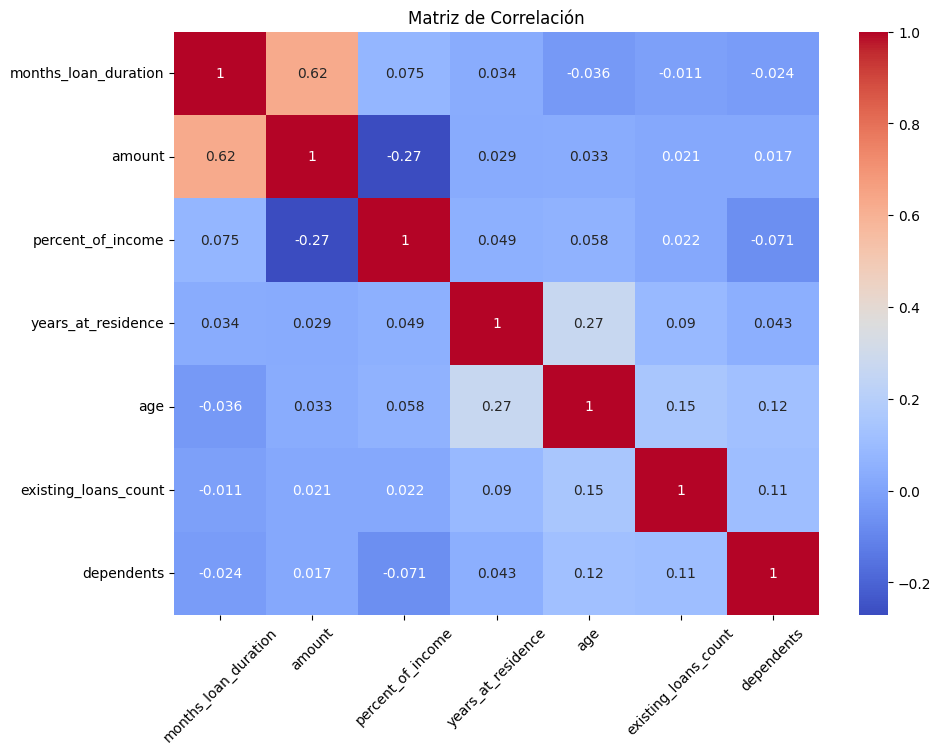

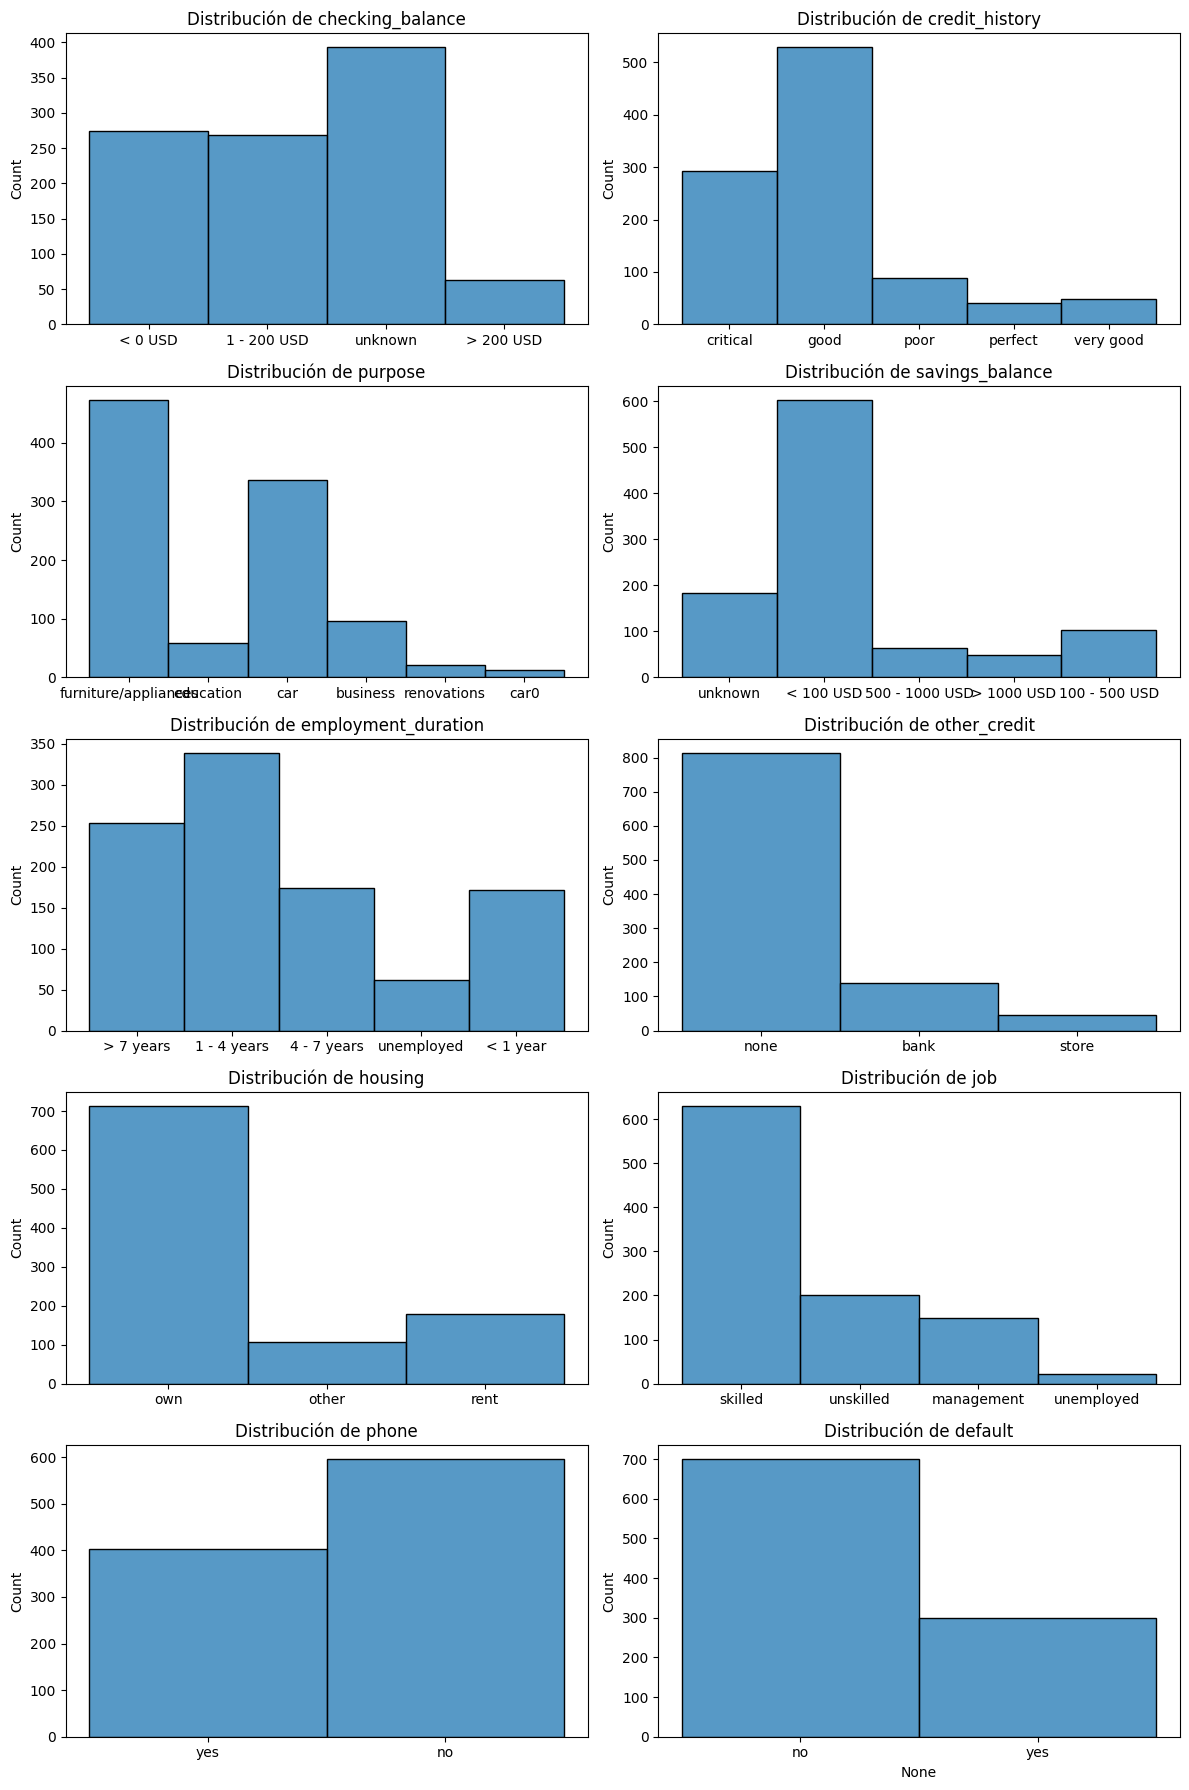

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt


# Correlacion entre variables numericas

plt.figure(figsize=(10, 8))
df_numericas = df.select_dtypes(include=['number'])
sns.heatmap(df_numericas.corr(), annot=True, cmap='coolwarm')
plt.title('Matriz de Correlación')
plt.tight_layout()
plt.xticks(rotation=45)
plt.show()
print()

# Graficos de barras para las variables categoricas

# Crear la figura de 5 filas x 2 columnas
fig, ax = plt.subplots(5, 2, figsize=(12, 18))

# Aplanar la matriz 'ax' para iterar fácilmente de 0 a 9
axes = ax.flatten()

# Lista de columnas que son las categoricas
columnas_categoricas = df.select_dtypes(include=['object']).columns

# Dibujar cada gráfico en su posición correspondiente
for i, col in enumerate(columnas_categoricas):
    sns.histplot(df[col], ax=axes[i]) #kde = True, para generar linea de tendencia
    axes[i].set_title(f'Distribución de {col}')
    axes[i].set_xlabel('')
    plt.xlabel("None")

plt.tight_layout()
plt.show()

*Se observa que no hay datos NaN en todo el DF*

## 2.   Detectar espacios en blanco y Valores únicos

In [ ]:
# Detectamos si hay valores en blanco en las columnas tipo texto, ya que en las númericas python lo deja como NaN

# Seleccionar solo las columnas de tipo texto
columnas_texto = df.select_dtypes(include=['object']).columns

# Contar celdas con solo espacios o vacías por cada columna
espacios_por_columna = {
    col: df[col].astype(str).str.strip().eq('').sum()
    for col in columnas_texto
}

# Mostrar para fácil lectura
print(pd.Series(espacios_por_columna))

# Ya que no hay valores NaN necesitamos conocer los valores unicos para los no numericos
for i in df.select_dtypes(include=['object']):
    print(f"Valores unicos de la columna {i}:")
    print(f"{df[i].unique()}\n")

checking_balance       0
credit_history         0
purpose                0
savings_balance        0
employment_duration    0
other_credit           0
housing                0
job                    0
phone                  0
default                0
dtype: int64
Valores unicos de la columna checking_balance:
['< 0 USD' '1 - 200 USD' 'unknown' '> 200 USD']

Valores unicos de la columna credit_history:
['critical' 'good' 'poor' 'perfect' 'very good']

Valores unicos de la columna purpose:
['furniture/appliances' 'education' 'car' 'business' 'renovations' 'car0']

Valores unicos de la columna savings_balance:
['unknown' '< 100 USD' '500 - 1000 USD' '> 1000 USD' '100 - 500 USD']

Valores unicos de la columna employment_duration:
['> 7 years' '1 - 4 years' '4 - 7 years' 'unemployed' '< 1 year']

Valores unicos de la columna other_credit:
['none' 'bank' 'store']

Valores unicos de la columna housing:
['own' 'other' 'rent']

Valores unicos de la columna job:
['skilled' 'unskilled' 'management

In [ ]:
# Para aplicar un ML Supervisado necesitamos que la columna default que es el resultado de:
#   Yes: Se le otorga el credito,
#   No: No se otorga el credito,
# sean valores 1 o 0, respectivamente. Aplicamos estos pasos:

# La columna "default" tiene formato texto (object) y debe ser transformada a entero (int)
# Limpiamos el texto (convertir a string, minúsculas y quitar espacios) para que todos sean iguales
# Reemplazamos 'yes' por 1 y 'no' por 0, puede que los valores aparezcan como NaN
# Rellenamos los valores NaN con 0 (si aparecen)
# Convertimos la columna final a número entero, adecuando el formato

df['default'] = df['default'].astype(str).str.lower().str.strip().map({'yes': 1, 'no': 0}).fillna(0).astype(int)

# La columna phone no representa una caracteristica relevante por lo que la sacamos del df original

df_limpio = df.drop('phone', axis=1)

display(df_limpio.head())

,checking_balance,months_loan_duration,credit_history,purpose,amount,savings_balance,employment_duration,percent_of_income,years_at_residence,age,other_credit,housing,existing_loans_count,job,dependents,default
0,< 0 USD,6,critical,furniture/appliances,1169,unknown,> 7 years,4,4,67,none,own,2,skilled,1,0
1,1 - 200 USD,48,good,furniture/appliances,5951,< 100 USD,1 - 4 years,2,2,22,none,own,1,skilled,1,1
2,unknown,12,critical,education,2096,< 100 USD,4 - 7 years,2,3,49,none,own,1,unskilled,2,0
3,< 0 USD,42,good,furniture/appliances,7882,< 100 USD,4 - 7 years,2,4,45,none,other,1,skilled,2,0
4,< 0 USD,24,poor,car,4870,< 100 USD,1 - 4 years,3,4,53,none,other,2,skilled,2,1


## 3.   Pipeline para preparar datos

In [ ]:
from sklearn.preprocessing import OrdinalEncoder, StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

# Separamos las variables para utilizar en el Pipeline
var_numericas = ['months_loan_duration', 'amount', 'percent_of_income', 'years_at_residence', 'age', 'existing_loans_count', 'dependents']
var_cat_ordinales = ['checking_balance', 'credit_history', 'savings_balance', 'employment_duration']
var_cat_nominales = ['purpose', 'housing', 'job', 'other_credit']

# Para columnas categoricas ordinales con rangos "['< 0 USD' '1 - 200 USD' 'unknown' '> 200 USD'"]" es mejor utilizar OrdinalEncoder en el Pipeline ya que debemos darle el rango al modelo.

orden_checking_balance = ['unknown', '< 0 USD', '1 - 200 USD', '> 200 USD']
orden_credit_history = ['critical', 'poor', 'good', 'very good', 'perfect']
orden_savings_balance = ['unknown','< 100 USD', '100 - 500 USD', '500 - 1000 USD', '> 1000 USD']
orden_employment_duration = ['unemployed', '< 1 year', '1 - 4 years', '4 - 7 years', '> 7 years']

# Creacion del Pipeline

preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), var_numericas),
        ('cat_ordinal', OrdinalEncoder(categories=[orden_checking_balance, orden_credit_history, orden_savings_balance, orden_employment_duration]), var_cat_ordinales),
        ('cat_nominal', OneHotEncoder(handle_unknown='ignore'), var_cat_nominales)
    ])

pipeline = Pipeline(steps=[("preprocessor", preprocessor)])

## 4.   Aplicar modelos ML supervisados: Random Forest y Logistic Regression Classifier

In [ ]:
# Aplicamos primero un modelo de Random Forest

from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, recall_score, f1_score, confusion_matrix

X1 = df_limpio.drop('default', axis=1)
y1 = df_limpio['default']

X_train1, X_test1, y_train1, y_test1 = train_test_split(X1, y1, test_size=0.2, random_state=42)

X_train1_procesado = pipeline.fit_transform(X_train1)
X_test1_procesado = pipeline.transform(X_test1)

# Entrenamiento del modelo RF
modelo_rf = RandomForestClassifier(n_estimators=100, max_depth=4, random_state=42)
modelo_rf.fit(X_train1_procesado, y_train1)

# Evaluacion del RF
y_pred_rf = modelo_rf.predict(X_test1_procesado)
print("Random Forest:")
print(f"Accuracy: {accuracy_score(y_test1, y_pred_rf)}")
print(f"Recall: {recall_score(y_test1, y_pred_rf):.3f}")
print(f"F1-Score: {f1_score(y_test1, y_pred_rf):.3f}")
print(f"Confusion Matrix:\n{confusion_matrix(y_test1, y_pred_rf)}")
print()

# Ahora aplicamos LogisticRegression

from sklearn.linear_model import LogisticRegression

# Entrenamiento de LR
modelo_lr = LogisticRegression(random_state=42)
modelo_lr.fit(X_train1_procesado, y_train1)

# Evaluacion de LR
y_pred_lr = modelo_lr.predict(X_test1_procesado)
print("Logistic Regression:")
print(f"Accuracy: {accuracy_score(y_test1, y_pred_lr)}")
print(f"Recall: {recall_score(y_test1, y_pred_lr):.3f}")
print(f"F1-Score: {f1_score(y_test1, y_pred_lr):.3f}")
print(f"Confusion Matrix:\n{confusion_matrix(y_test1, y_pred_lr)}")

Random Forest:
Accuracy: 0.735
Recall: 0.136
F1-Score: 0.232
Confusion Matrix:
[[139   2]
 [ 51   8]]

Logistic Regression:
Accuracy: 0.715
Recall: 0.288
F1-Score: 0.374
Confusion Matrix:
[[126  15]
 [ 42  17]]


## 5.   Optimizar modelos supervisados

In [ ]:
# Optimizamos a RF

from sklearn.model_selection import GridSearchCV

# Definimos un grid de búsqueda de hiperparámetros
param_grid_rf = {
    'n_estimators': [100, 200, 300],
    'max_depth': [6, 10, 15],
    'max_features': ['sqrt', 0.4],
    'class_weight': ['balanced', 'balanced_subsample']
    }
modelo_op_rf = RandomForestClassifier(random_state=42)
grid_search = GridSearchCV(modelo_op_rf, param_grid_rf, cv=5, scoring='f1', n_jobs=-1)
grid_search.fit(X_train1_procesado, y_train1)

# Mejor modelo para RF usando GridSearch
mejor_modelo_rf = grid_search.best_estimator_
print('Random Forest:')
print('Precisión en test:', mejor_modelo_rf.score(X_test1_procesado, y_test1))
print('Mejores hiperparámetros:', grid_search.best_params_)
print("Recall:", round(recall_score(y_test1, mejor_modelo_rf.predict(X_test1_procesado)), 3))
print(f"F1-Score: {f1_score(y_test1, mejor_modelo_rf.predict(X_test1_procesado)):.3f}")
print(f"Confusion Matrix:\n{confusion_matrix(y_test1, mejor_modelo_rf.predict(X_test1_procesado))}")
print()

# Optimizamos para LR

param_grid_lr = {
    "C" : [0.01, 0.1, 1, 10],
    "penalty" : ["l1", "l2"],
    "solver" : ["liblinear"], # Para la compatibilidad con l1
    "class_weight" : ["balanced"]
    }

modelo_op_lr = LogisticRegression(random_state=42)
grid_search2 = GridSearchCV(modelo_op_lr, param_grid_lr, cv=5, scoring='f1', n_jobs=-1)
grid_search2.fit(X_train1_procesado, y_train1)

# Mejor modelo para LR usando GridSearch
mejor_modelo_lr = grid_search2.best_estimator_
print('Logistic Regression:')
print('Precisión en test:', mejor_modelo_lr.score(X_test1_procesado, y_test1))
print('Mejores hiperparámetros:', grid_search2.best_params_)
print("Recall:", round(recall_score(y_test1, mejor_modelo_lr.predict(X_test1_procesado)), 3))
print(f"F1-Score: {f1_score(y_test1, mejor_modelo_lr.predict(X_test1_procesado)):.3f}")
print(f"Confusion Matrix:\n{confusion_matrix(y_test1, mejor_modelo_lr.predict(X_test1_procesado))}")

Random Forest:
Precisión en test: 0.735
Mejores hiperparámetros: {'class_weight': 'balanced', 'max_depth': 6, 'max_features': 0.4, 'n_estimators': 100}
Recall: 0.644
F1-Score: 0.589
Confusion Matrix:
[[109  32]
 [ 21  38]]

Logistic Regression:
Precisión en test: 0.63
Mejores hiperparámetros: {'C': 0.01, 'class_weight': 'balanced', 'penalty': 'l2', 'solver': 'liblinear'}
Recall: 0.525
F1-Score: 0.456
Confusion Matrix:
[[95 46]
 [28 31]]


## 6.   Comparar Resultados y modelo elegido

In [ ]:
# Tabla comparativa de modelos base vs optimizados para RF y LR segun su F1-Score

f1_rf_base = f1_score(y_test1, y_pred_rf)
f1_lr_base = f1_score(y_test1, y_pred_lr)
f1_rf_op = f1_score(y_test1, mejor_modelo_rf.predict(X_test1_procesado))
f1_lr_op = f1_score(y_test1, mejor_modelo_lr.predict(X_test1_procesado))

resultados = [
    {
        "Modelo": "Random Forest",
     "F1 Score Base": f1_rf_base,
     "F1 Score Opt": f1_rf_op,
     "Mejora Relativa": (f1_rf_op - f1_rf_base) / f1_rf_base
        },
    {"Modelo": "Logistic Regression",
     "F1 Score Base": f1_lr_base,
     "F1 Score Opt": f1_lr_op,
     "Mejora Relativa": (f1_lr_op - f1_lr_base) / f1_lr_base
        }
]

tabla_comparativa = pd.DataFrame(resultados)

tabla_formateada = tabla_comparativa.copy()
tabla_formateada['F1 Score Base'] = tabla_formateada['F1 Score Base'].apply(lambda x: f'{x:.3f}')
tabla_formateada['F1 Score Opt'] = tabla_formateada['F1 Score Opt'].apply(lambda x: f'{x:.3f}')
tabla_formateada['Mejora Relativa'] = tabla_formateada['Mejora Relativa'].apply(lambda x: f'{x*100:.2f}%')

tabla_formateada.style.highlight_max(subset=['F1-Score Opt'], color='lightgreen')

display(tabla_formateada.style.hide())

# Por que un modelo es mejor que el otro comparando la relacion de variables seleccionadas

print("""
Se elige el modelo de Random Forest ya que presenta un mejor modelo segun los parametros Accuracy y Recall.
Se pueden obtener mejores modelos ajustando hiperparametros y mejorando precision, pero sacrificando un mayor numero de Falsos Negativos (FN).

Con este modelo, de las 200 evaluaciones (20% de la muestra) obtenemos un numero de 21 creditos mal aprobados
correspondiente a un 10,5% (Falsos Negativos) y un 73,5% de Creditos bien evaluados.

""")

Modelo,F1 Score Base,F1 Score Opt,Mejora Relativa
Random Forest,0.232,0.589,154.07%
Logistic Regression,0.374,0.456,22.02%



Se elige el modelo de Random Forest ya que presenta un mejor modelo segun los parametros Accuracy y Recall, ya que se pueden 
obtener mejores modelos ajustando hiperparametros mejorando precision pero sacrificando un mayor numero de Falsos Negativos (FN).

Con este modelo, de las 200 evaluaciones (20% de la muestra) obtenemos un numero de 21 creditos mal aprobados 
correspondiente a un 10,5% (Falsos Negativos) y un 73,5% de Creditos bien evaluados


